# Exercise 3 — Regularization

## Part A — Why Do Models Overfit?

As models become more complex, they can start learning:

* noise
* random fluctuations
* training examples by heart

instead of learning the true underlying pattern.

This is called, as you already know now, `overfitting`.

Intuition

A very flexible model can perfectly fit the training data: `training error ↓`
But may fail on new unseen data: `test error ↑`

### Goal of Regularization

Regularization helps prevent models from becoming too complex.

It encourages:

* simpler models
* smoother decision boundaries
* better generalization

### Main Idea

Instead of minimizing only the prediction error: `Loss`

we also penalize large weights: `Loss + λ × Complexity Penalty`

### What Does λ (Lambda) Do?

`small λ → weak regularization`

`large λ → strong regularization`

Small λ

* flexible model
* risk of overfitting

Large λ

* simpler model
* risk of underfitting

`Regularization controls model complexity.`

## Part B — Polynomial Regression With and Without Regularization

Let's simulate some data.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error

np.random.seed(42)

# We create a small synthetic dataset from a sine function.
# The true function is smooth, but the observations contain noise.
X = np.linspace(0, 10, 28).reshape(-1, 1)
y_true = np.sin(X).ravel()
y = y_true + np.random.normal(0, 0.45, size=y_true.shape)

# We split the data into training and test sets.
# The model only learns from the training data.
# The test data is used to check whether the model generalizes.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.35, random_state=42
)

# Points used only for drawing smooth curves
x_plot = np.linspace(0, 10, 500).reshape(-1, 1)
# y_true_plot = np.sin(x_plot).ravel()


## Without Ridge regularization

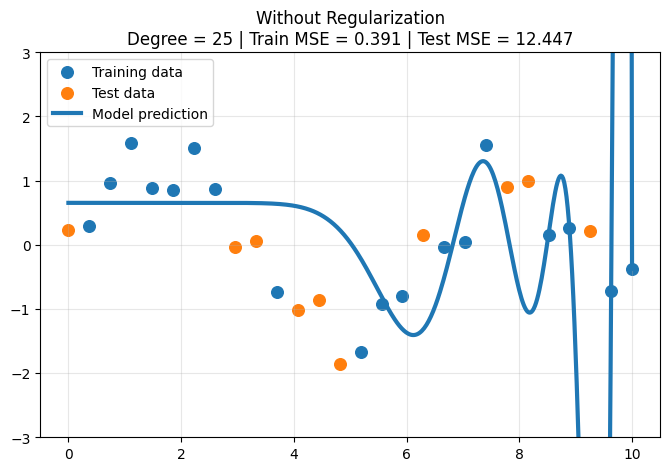

In [3]:
degree = 25

model_no_reg = make_pipeline(
    PolynomialFeatures(degree, include_bias=False),
    LinearRegression()
)

model_no_reg.fit(X_train, y_train)

y_plot_no_reg = model_no_reg.predict(x_plot)
y_train_pred_no_reg = model_no_reg.predict(X_train)
y_test_pred_no_reg = model_no_reg.predict(X_test)

train_mse_no_reg = mean_squared_error(y_train, y_train_pred_no_reg)
test_mse_no_reg = mean_squared_error(y_test, y_test_pred_no_reg)

plt.figure(figsize=(8, 5))

plt.scatter(X_train, y_train, label="Training data", s=70)
plt.scatter(X_test, y_test, label="Test data", s=70)

# 
# plt.plot(x_plot, y_true_plot, "--", linewidth=2, label="True function")
plt.plot(x_plot, y_plot_no_reg, linewidth=3, label="Model prediction")

plt.title(
    f"Without Regularization\n"
    f"Degree = {degree} | Train MSE = {train_mse_no_reg:.3f} | Test MSE = {test_mse_no_reg:.3f}"
)

plt.ylim(-3, 3)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## With Ridge regularization

Regularization controls how flexible the model is allowed to be.

```
alpha = 0      means almost no regularization
```

* small alpha - means weak regularization
* large alpha - means strong regularization

Try changing alpha:
```
alpha = 0.01
alpha = 0.1
alpha = 1
alpha = 10
alpha = 100
```
or higher values and see what happens!

/Users/admin/myenv/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


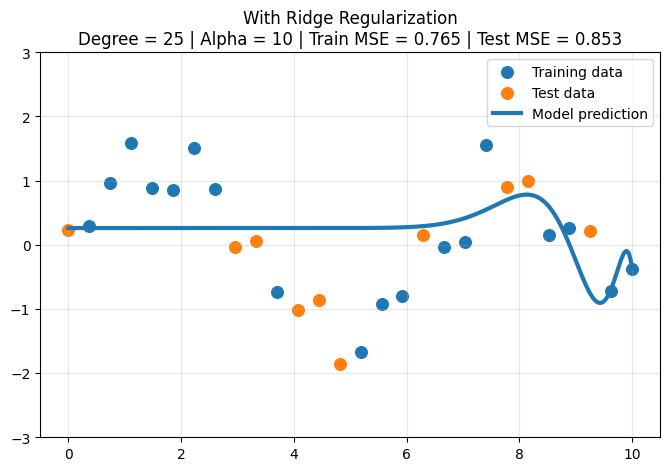

In [5]:
alpha = 10

model_reg = make_pipeline(
    PolynomialFeatures(degree, include_bias=False),
    StandardScaler(),
    Ridge(alpha=alpha)
)

model_reg.fit(X_train, y_train)

y_plot_reg = model_reg.predict(x_plot)
y_train_pred_reg = model_reg.predict(X_train)
y_test_pred_reg = model_reg.predict(X_test)

train_mse_reg = mean_squared_error(y_train, y_train_pred_reg)
test_mse_reg = mean_squared_error(y_test, y_test_pred_reg)

plt.figure(figsize=(8, 5))

plt.scatter(X_train, y_train, label="Training data", s=70)
plt.scatter(X_test, y_test, label="Test data", s=70)

plt.plot(x_plot, y_plot_reg, linewidth=3, label="Model prediction")

plt.title(
    f"With Ridge Regularization\n"
    f"Degree = {degree} | Alpha = {alpha} | Train MSE = {train_mse_reg:.3f} | Test MSE = {test_mse_reg:.3f}"
)

plt.ylim(-3, 3)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Questions

1. What happens when λ becomes very small?
2. What happens when λ becomes very large?
3. Which value seems best?
4. Which model underfits?
5. Which model overfits?

ANSWER
1. Small λ - complex model - overfitting - weak regularization.
2. Large λ - simple model - underfitting - strong regularization.
3. The best value seem to be between 1 to 10 because the model is
moderate, no overfitting, train MSE and test MSE are closed to each other
5. The model with regularization with Loss = MSE + λ × (sum of squared
coefficients) so the lambda is very large so it is underfitting
6. The model without regularization and with degree = 25 and no penalty
so Loss = MSE and it is be overfit

## With Lasso regularization


In [ ]:
from sklearn.linear_model import Lasso

alpha = 10

max_iter = 10000

model_lasso = make_pipeline(
    PolynomialFeatures(degree, include_bias=False),
    StandardScaler(),
    Lasso(alpha=alpha, max_iter=max_iter)
)

model_lasso.fit(X_train, y_train)

y_plot_lasso = model_lasso.predict(x_plot)
y_train_pred_lasso = model_lasso.predict(X_train)
y_test_pred_lasso = model_lasso.predict(X_test)

train_mse_lasso = mean_squared_error(y_train, y_train_pred_lasso)
test_mse_lasso = mean_squared_error(y_test, y_test_pred_lasso)

plt.figure(figsize=(8, 5))

plt.scatter(X_train, y_train, label="Training data", s=70)
plt.scatter(X_test, y_test, label="Test data", s=70)

plt.plot(x_plot, y_plot_lasso, linewidth=3, label="Lasso model prediction")

plt.title(
    f"With Lasso Regularization\n"
    f"Degree = {degree} | Alpha = {alpha} | "
    f"Train MSE = {train_mse_lasso:.3f} | Test MSE = {test_mse_lasso:.3f}"
)

plt.ylim(-3, 3)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Same questions.

Let's also inspect the weights. Did any of them go to zero?
- Yes, most of them go to zero because that its behavior.
- With alpha = 10 (quite large), Lasso will likely zero out most of the polynomial feature coefficients.

In [ ]:
lasso_model = model_lasso.named_steps["lasso"]

print("Lasso coefficients:")
for i, coef in enumerate(lasso_model.coef_, start=1):
    print(f"x^{i}: {coef:.6f}")

print("Bias:", lasso_model.intercept_)